# PPMI Longitudinal Results

Pipeline: same longitudinal aggregation framework as NKI (Arms A, B, B2 + PD/HC classification).  
Dataset: PPMI Parkinson's disease cohort — 2 sessions per subject (BL + V04).  
Bands: **PD** (PPMI_PD) and **HC** (healthy controls, PPMI_HC).  
Features: FreeSurfer ROI (Destrieux atlas, available first); CNN features will populate as extraction completes.

⚠️ **Note:** FS ROI features here use the Destrieux atlas (505 features), not Desikan-Killiany as in NKI.  
CNN features are architecturally identical across datasets and directly comparable.


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

_cwd = Path().resolve()
if   (_cwd        / 'brainage_agg' / 'ppmi_outputs' / 'results.csv').exists():
    root_dir = _cwd
elif (_cwd.parent / 'brainage_agg' / 'ppmi_outputs' / 'results.csv').exists():
    root_dir = _cwd.parent
else:
    raise FileNotFoundError('Cannot locate brainage_agg/ppmi_outputs/results.csv from ' + str(_cwd))

sns.set_theme(style='whitegrid', font_scale=1.1)

AGG_ORDER_A = ['mean', 'concatenation', 'annualized_rate', 'lme_slope']
AGG_ORDER_B = ['annualized_rate', 'lme_slope_change', 'difference', 'mean', 'concatenation']
AGG_LABELS  = {
    'mean': 'Mean', 'concatenation': 'Concat',
    'annualized_rate': 'Ann. Rate', 'lme_slope': 'LME Slope',
    'difference': 'Difference', 'lme_slope_change': 'LME Slope\n(change)',
}
PALETTE     = {'fs_roi': '#2196F3', 'cnn': '#FF9800'}

# Load results — handle leakage_warning gracefully
df = pd.read_csv(root_dir / 'brainage_agg/ppmi_outputs/results.csv')
if 'leakage_warning' not in df.columns:
    df['leakage_warning'] = False
df['leakage_warning'] = df['leakage_warning'].fillna(False)

print(f'{len(df):,} rows | arms: {sorted(df["target_arm"].unique())} | extractors: {df["extractor"].nunique()}')
print('Extractor types:', df[['extractor_type','extractor']].drop_duplicates()['extractor_type'].value_counts().to_dict())


## 1  Cohort overview


In [ ]:
manifest = pd.read_csv(root_dir / 'brainage_agg/ppmi_outputs/manifest.csv')
manifest['ages'] = manifest['ages'].apply(json.loads)

all_ages = [a for ages in manifest['ages'] for a in ages]
print(f'Subjects: {len(manifest)} | Sessions/subject: {manifest["n_timepoints"].value_counts().to_dict()}')
print(f'Band distribution: {manifest["band"].value_counts().to_dict()}')
print(f'cohort_all (≥2 tp): {manifest["cohort_all"].sum()} | cohort_concat (≥3 tp): {manifest["cohort_concat"].sum()}')
if 'cohort_span1' in manifest.columns:
    n_s1 = manifest["cohort_span1"].sum()
    n_s1_pd = manifest[manifest["band"]=="PD"]["cohort_span1"].sum()
    n_s1_hc = manifest[manifest["band"]=="HC"]["cohort_span1"].sum()
    print(f'cohort_span1 (δt≤1.5yr): {n_s1} | PD={n_s1_pd}  HC={n_s1_hc}')
print(f'Age: min={min(all_ages):.1f}  max={max(all_ages):.1f}  mean={np.mean(all_ages):.1f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution by band
ax = axes[0]
for band, color in [("PD","#E53935"), ("HC","#43A047")]:
    sub = manifest[manifest["band"]==band]
    ages_sub = [a for row_ages in sub["ages"] for a in row_ages]
    ax.hist(ages_sub, bins=12, color=color, alpha=0.6, label=f"{band} (n={len(sub)})")
ax.set(xlabel="Age (years)", ylabel="Count", title="Age Distribution by Band")
ax.legend()

# Sessions per subject
ax = axes[1]
ntp_counts = manifest["n_timepoints"].value_counts().sort_index()
ax.bar(ntp_counts.index.astype(str), ntp_counts.values, color="#5C6BC0")
ax.set(xlabel="Sessions per subject", ylabel="Count", title="Sessions per Subject")

# delta_t distribution by band
ax = axes[2]
for band, color in [("PD","#E53935"), ("HC","#43A047")]:
    sub = manifest[(manifest["band"]==band) & (manifest["delta_t"]>0)]
    ax.hist(sub["delta_t"], bins=15, color=color, alpha=0.6, label=f"{band} (n={len(sub)})")
if "cohort_span1" in manifest.columns:
    ax.axvline(1.5, color="black", linestyle="--", lw=1.5, label="cutoff δt=1.5yr")
ax.set(xlabel="Follow-up span (years)", ylabel="Count", title="Follow-up Span")
ax.legend()

plt.suptitle("PPMI Cohort Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
fig_dir = root_dir / "brainage_agg/ppmi_outputs/figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "cohort_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## 2  Arm A — Age prediction

State aggregations (mean, concat) expected to outperform change aggregations for age prediction.  
PPMI has only 2 sessions per subject → `concatenation` available; `lme_slope` and `annualized_rate` too.


In [ ]:
arm_a = df[(df['target_arm']=='A') & (df['age_band']=='all')].copy()
if arm_a.empty:
    print('Arm A results not yet available.')
else:
    arm_a['ext_label'] = arm_a['extractor_type'].map({'fs_roi':'FS ROI','cnn':'CNN (all)'})
    available_exts = arm_a['ext_label'].dropna().unique()

    ncols = len(available_exts)
    fig, axes = plt.subplots(1, max(ncols, 1), figsize=(7*ncols, 5), sharey=False, squeeze=False)
    for ax, ext in zip(axes[0], available_exts):
        sub    = arm_a[arm_a['ext_label']==ext]
        by_ext = sub.groupby(['aggregation','extractor','fold'])['MAE'].mean().reset_index()
        by_agg = by_ext.groupby('aggregation')['MAE'].agg(['mean','std']).reindex(AGG_ORDER_A).dropna().reset_index()
        by_agg['label'] = by_agg['aggregation'].map(AGG_LABELS)
        colors = ['#43A047' if a in ['mean','concatenation'] else '#E53935' for a in by_agg['aggregation']]
        bars   = ax.bar(by_agg['label'], by_agg['mean'], color=colors, alpha=0.85,
                        yerr=by_agg['std'], capsize=4, error_kw={'lw':1.5})
        ax.set(ylabel='MAE (years)', title=f'Arm A — {ext}')
        for bar, v in zip(bars, by_agg['mean']):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    axes[0][-1].legend(handles=[
        mpatches.Patch(color='#43A047', label='State (expected to win)'),
        mpatches.Patch(color='#E53935', label='Change (expected to lose)')], fontsize=9)
    plt.suptitle('Arm A: Age Prediction MAE by Aggregation (PPMI)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'arm_a_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Arm A summary (mean MAE):')
    print(arm_a.groupby(['aggregation','ext_label'])['MAE'].mean().round(3).to_string())


## 3  Arm B — Brain change rate prediction

Change aggregations (difference, annualized rate, LME slope change) expected to outperform state aggregations.  
Target: PC1 of annualized FS ROI feature change (Destrieux atlas for PPMI).


In [ ]:
arm_b = df[(df['target_arm']=='B') & (df['age_band']=='all')].copy()
if arm_b.empty:
    print('Arm B results not yet available.')
else:
    arm_b['ext_label'] = arm_b['extractor_type'].map({'fs_roi':'FS ROI','cnn':'CNN (all)'})
    chance_mae_b = arm_b['chance_mae'].mean()
    available_exts = arm_b['ext_label'].dropna().unique()

    ncols = len(available_exts)
    fig, axes = plt.subplots(1, max(ncols, 1), figsize=(7*ncols, 5), sharey=False, squeeze=False)
    for ax, ext in zip(axes[0], available_exts):
        sub    = arm_b[arm_b['ext_label']==ext]
        by_ext = sub.groupby(['aggregation','extractor','fold'])['MAE'].mean().reset_index()
        by_agg = by_ext.groupby('aggregation')['MAE'].agg(['mean','std']).reindex(AGG_ORDER_B).dropna().reset_index()
        by_agg['label'] = by_agg['aggregation'].map(AGG_LABELS)
        is_ch  = by_agg['aggregation'].isin(['annualized_rate','difference','lme_slope_change'])
        bars   = ax.bar(by_agg['label'], by_agg['mean'],
                        color=['#1565C0' if x else '#B0BEC5' for x in is_ch],
                        alpha=0.85, yerr=by_agg['std'], capsize=4, error_kw={'lw':1.5})
        ax.axhline(chance_mae_b, color='red', linestyle='--', lw=1.5,
                   label=f'Null = {chance_mae_b:.3f}')
        ax.set(ylabel='MAE', title=f'Arm B — {ext}')
        ax.legend(fontsize=8)
        for bar, v in zip(bars, by_agg['mean']):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01*bar.get_height(),
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.suptitle('Arm B: Brain Change Rate (PPMI) — MAE by Aggregation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'arm_b_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


## 4  Arm B2 — eTIV rate prediction

⚠️ **FS ROI leakage warning:** eTIV is from FreeSurfer aseg.stats, correlated with FS ROI features.  
CNN results (free of leakage) will appear once extraction completes.


In [ ]:
arm_b2 = df[(df['target_arm']=='B2') & (df['age_band']=='all')].copy()
if arm_b2.empty:
    print('Arm B2 results not yet available.')
else:
    arm_b2['ext_label'] = arm_b2['extractor_type'].map({'fs_roi':'FS ROI','cnn':'CNN (all)'})
    chance_mae_b2 = arm_b2['chance_mae'].mean()
    available_exts = arm_b2['ext_label'].dropna().unique()

    ncols = len(available_exts)
    fig, axes = plt.subplots(1, max(ncols, 1), figsize=(7*ncols, 5), sharey=False, squeeze=False)
    for ax, ext in zip(axes[0], available_exts):
        sub    = arm_b2[arm_b2['ext_label']==ext]
        by_ext = sub.groupby(['aggregation','extractor','fold'])['MAE'].mean().reset_index()
        by_agg = by_ext.groupby('aggregation')['MAE'].agg(['mean','std']).reindex(AGG_ORDER_B).dropna().reset_index()
        by_agg['label'] = by_agg['aggregation'].map(AGG_LABELS)
        is_ch  = by_agg['aggregation'].isin(['annualized_rate','difference','lme_slope_change'])
        bars   = ax.bar(by_agg['label'], by_agg['mean'],
                        color=['#1565C0' if x else '#B0BEC5' for x in is_ch],
                        alpha=0.85, yerr=by_agg['std'], capsize=4, error_kw={'lw':1.5})
        ax.axhline(chance_mae_b2, color='red', linestyle='--', lw=1.5,
                   label=f'Null = {chance_mae_b2:.0f} mm³/yr')
        ax.set(ylabel='MAE (mm³/year)', title=f'Arm B2 — {ext}')
        ax.legend(fontsize=8)
        for bar, v in zip(bars, by_agg['mean']):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01*bar.get_height(),
                    f'{v:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    if 'FS ROI' in available_exts:
        axes[0][0].annotate('⚠ Residual FS leakage\n(eTIV ∈ FS features)',
                            xy=(0.98, 0.97), xycoords='axes fraction',
                            ha='right', va='top', fontsize=8, color='#B71C1C',
                            bbox=dict(boxstyle='round,pad=0.3', fc='#FFEBEE', ec='#B71C1C', alpha=0.8))

    plt.suptitle('Arm B2: eTIV Rate (PPMI) — MAE by Aggregation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'arm_b2_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Arm B2: chance MAE = {chance_mae_b2:.0f} mm³/yr')
    print('Arm B2 summary:')
    print(arm_b2.groupby(['aggregation','ext_label'])['MAE'].mean().round(0).to_string())


## 5  PD/HC Classification

Aggregated CNN/ROI features used as input to LR and RF classifiers for PD vs HC discrimination.  
Positive class: PD.  Metrics: AUC, balanced accuracy.


In [ ]:
_classif_path = root_dir / 'brainage_agg/ppmi_outputs/classification_results.csv'
if not _classif_path.exists():
    print('Classification results not yet available. Run submit_ppmi_classif.sh after feature extraction completes.')
else:
    from scipy import stats as scipy_stats
    from itertools import product as _itp

    clf_df = pd.read_csv(_classif_path)
    print(f'{len(clf_df):,} rows | extractors: {clf_df["extractor"].nunique()}')

    AGG_ORDER_CL = ['cross_sectional','mean','concatenation','annualized_rate','difference','lme_slope_change']
    AGG_LABELS_CL = {
        'cross_sectional': 'Cross-\nsectional',
        'mean':            'Mean',
        'concatenation':   'Concat',
        'annualized_rate': 'Ann.\nRate',
        'difference':      'Difference',
        'lme_slope_change':'LME\nSlope',
    }
    CLF_COLORS = {'LogisticReg': '#1976D2', 'RandomForest': '#E64A19'}

    fs_df  = clf_df[clf_df['extractor_type']=='fs_roi'].copy()
    cnn_cl = clf_df[clf_df['extractor_type']=='cnn'].copy()

    summary_fs = (fs_df.groupby(['aggregation','classifier'])[['bacc','auc']]
                  .agg(['mean','std']).reset_index())
    summary_fs.columns = ['aggregation','classifier','bacc_mean','bacc_std','auc_mean','auc_std']

    # Best CNN config per metric (highest mean across all aggs × classifiers)
    cnn_cfg = (cnn_cl.groupby(['cnn_arch','scaler','channels','cnn_seed','aggregation','classifier'])
               [['bacc','auc']].mean().reset_index())
    best_cnn_configs = {}
    for metric in ['bacc','auc']:
        idx = cnn_cfg.groupby(['cnn_arch','scaler','channels'])[metric].mean().idxmax()
        best_cnn_configs[metric] = idx  # (arch, scaler, channels)

    def get_best_cnn(metric):
        # Best CNN config per metric (highest mean across all archs × aggs × classifiers)
        arch, scaler, channels = best_cnn_configs[metric]
        return cnn_cl[(cnn_cl['cnn_arch']==arch) &
                      (cnn_cl['scaler']==scaler) &
                      (cnn_cl['channels']==channels) 
                      ].copy(), arch, scaler, channels

    def summarize(sub):
        # Aggregate by (agg, clf) then unstack to ensure all aggs are present, fill missing with NaN/0
        s = (sub.groupby(['aggregation','classifier'])[['bacc','auc']]
             .agg(['mean','std']).reset_index())
        s.columns = ['aggregation','classifier','bacc_mean','bacc_std','auc_mean','auc_std']
        return s


    x = np.arange(len(AGG_ORDER_CL))
    w = 0.35

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    from statsmodels.stats.multitest import multipletests
    _metric_tests = {0: [], 1: []}  # col_idx → [(ax, xi, i_clf, p_raw)]

    for row_idx, (row_label, sub_df, extra) in enumerate([
        ('FS ROI',     fs_df,  ''),
        ('CNN best',   None,   None),   # filled per metric below
    ]):
        for col_idx, (metric, metric_std, ylabel) in enumerate([
            ('bacc_mean', 'bacc_std', 'Balanced Accuracy'),
            ('auc_mean',  'auc_std',  'AUC-ROC'),
        ]):
            _cur_metric = metric.replace('_mean','')
            ax = axes[row_idx][col_idx]

            if row_idx == 0:
                summary = summary_fs
                raw_df  = fs_df
                title   = f'FS ROI — {ylabel}'
            else:
                best_sub, arch, scaler, channels = get_best_cnn(_cur_metric)
                summary = summarize(best_sub)
                raw_df  = best_sub
                title   = f'CNN best ({arch[:3]}/{scaler}/{channels}) — {ylabel}'

            for i, clf in enumerate(['LogisticReg', 'RandomForest']):
                sub = summary[summary['classifier']==clf].set_index('aggregation')
                vals = [sub.loc[a, metric] if a in sub.index else np.nan for a in AGG_ORDER_CL]
                errs = [sub.loc[a, metric_std] if a in sub.index else 0  for a in AGG_ORDER_CL]
                bars = ax.bar(x + i*w, vals, w, label=clf, color=CLF_COLORS[clf],
                              alpha=0.85, yerr=errs, capsize=4, error_kw={'lw':1.5})
                for bar, v, e in zip(bars, vals, errs):
                    if not np.isnan(v):
                        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+e+0.004,
                                f'{v:.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

            # One-sample t-test vs chance=0.5 (more power than permutation with n=5 folds)
            _clf_order = ['LogisticReg', 'RandomForest']
            _pairs = [(clf, a) for clf in _clf_order for a in AGG_ORDER_CL]
            _data  = np.array([
                raw_df[(raw_df['aggregation']==a) &
                       (raw_df['classifier']==clf)]
                .groupby('fold')[_cur_metric].mean()
                .sort_index().values
                for clf, a in _pairs
            ])                                                    # (n_pairs, n_folds)
            _pvals = np.array([
                scipy_stats.ttest_1samp(_data[ki], popmean=0.5, alternative='greater').pvalue
                for ki in range(len(_pairs))
            ])
            for ki, (clf, a) in enumerate(_pairs):
                _metric_tests[col_idx].append(
                    (ax, AGG_ORDER_CL.index(a), _clf_order.index(clf), _pvals[ki]))

            ax.axhline(0.5, color='grey', linestyle='--', lw=1.2, alpha=0.7, label='Chance (0.5)')
            ax.set_xticks(x+w/2)
            ax.set_xticklabels([AGG_LABELS_CL.get(a,a) for a in AGG_ORDER_CL], fontsize=9)
            ax.set(ylabel=ylabel, title=title, ylim=(0.25, 1.01))
            ax.legend(fontsize=9, loc='lower left')
            ax.vlines(2.7, 0, 1.1, color='grey', linestyle=':', lw=0.8, alpha=0.7)

    # BH-FDR per metric column (24 tests = 2 extractors × 2 clf × 6 aggs)
    for _col, _tests in _metric_tests.items():
        if _tests:
            _praw = np.array([t[3] for t in _tests])
            _rej, _pcorrected, _, _ = multipletests(_praw, alpha=0.05, method='fdr_bh')
            for (_ax, _xi, _i, _), _sig in zip(_tests, _rej):
                if _sig:
                    _ax.text(_xi + _i*w, 0.9, '*', ha='center', va='bottom',
                             fontsize=13, fontweight='bold', color='black')

    plt.suptitle('PD vs HC Classification  (* = one-sample t-test vs chance=0.5, BH-FDR q < 0.05, n=24 per metric)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'classif_fsroi_cnn.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
if '_classif_path' in dir() and _classif_path.exists() and len(cnn_cl) > 0:
    cnn_cl_per_file = (cnn_cl.groupby(['cnn_arch','scaler','channels','cnn_seed','aggregation','classifier'])
                       [['bacc','auc']].mean().reset_index())
    aggs_shown    = ['cross_sectional','mean','concatenation','annualized_rate','difference','lme_slope_change']
    scalers       = ['minmax','zscore','robust']
    scaler_colors = {'minmax':'#EF5350','zscore':'#FFA726','robust':'#66BB6A'}
    x = np.arange(len(aggs_shown))
    w = 0.25

    for metric, ylabel in [('bacc','Balanced Accuracy'), ('auc','AUC-ROC')]:
        # Average over seeds first so best-config selection and fold values
        # are unbiased by lucky seed draws
        _seed_avg = (cnn_cl
                     .groupby(['cnn_arch','scaler','channels','aggregation','classifier','fold'])
                     [[metric]].mean().reset_index())
        _cfg_mean = (_seed_avg
                     .groupby(['cnn_arch','scaler','channels','aggregation','classifier'])
                     [metric].mean().reset_index())
        idx_best = _cfg_mean.groupby(['scaler','aggregation','classifier'])[metric].idxmax()
        best_configs = _cfg_mean.loc[idx_best][
            ['scaler','aggregation','classifier','cnn_arch','channels', metric]
        ].rename(columns={metric:'best_val'}).reset_index(drop=True)

        # Fold-level values: seed-averaged for the best (arch, channels) per (scaler, agg, clf)
        _best_cnn_folds = {}
        for _, _bc in best_configs.iterrows():
            _k = (_bc['scaler'], _bc['aggregation'], _bc['classifier'])
            _fc = _seed_avg[
                (_seed_avg['cnn_arch']    == _bc['cnn_arch'])   &
                (_seed_avg['scaler']      == _bc['scaler'])     &
                (_seed_avg['channels']    == _bc['channels'])   &
                (_seed_avg['aggregation'] == _bc['aggregation'])&
                (_seed_avg['classifier']  == _bc['classifier'])
            ]
            _best_cnn_folds[_k] = _fc.sort_values('fold')[metric].values

        fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
        from statsmodels.stats.multitest import multipletests
        _all_candidates = []  # (ax, xi, i_scaler, bv, p_raw) — across both clfs
        for ax, clf in zip(axes, ['LogisticReg', 'RandomForest']):
            sub_dist = cnn_cl_per_file[cnn_cl_per_file['classifier']==clf]
            sub_best = best_configs[best_configs['classifier']==clf]

            for i, scaler in enumerate(scalers):
                positions = x + (i - 1) * w

                data = [sub_dist[(sub_dist['scaler']==scaler) &
                                 (sub_dist['aggregation']==a)][metric].values for a in aggs_shown]
                bp = ax.boxplot(data, positions=positions, widths=w*0.8,
                                patch_artist=True, notch=False,
                                medianprops={'color':'grey','lw':1},
                                whiskerprops={'lw':0.8,'color':'grey'},
                                capprops={'lw':0.8,'color':'grey'},
                                flierprops={'marker':'.','markersize':2,'alpha':0.2,'color':'grey'})
                for patch in bp['boxes']:
                    patch.set_facecolor('#EEEEEE'); patch.set_alpha(0.5)

                s_best = sub_best[sub_best['scaler']==scaler]
                for xi, a in enumerate(aggs_shown):
                    row = s_best[s_best['aggregation']==a]
                    if len(row):
                        bv = row['best_val'].values[0]
                        ax.scatter(xi + (i-1)*w, bv, marker='D', s=60,
                                   color=scaler_colors[scaler], zorder=5,
                                   edgecolors='black', linewidths=0.5)
                        ax.text(xi + (i-1)*w, bv + 0.008, f'{bv:.3f}',
                                ha='center', va='bottom', fontsize=6,
                                color=scaler_colors[scaler], fontweight='bold')
                        _cnn_f = _best_cnn_folds.get((scaler, a, clf), np.array([]))
                        if len(_cnn_f) >= 2 and bv > 0.5:
                            _p_raw = scipy_stats.ttest_1samp(
                                _cnn_f, popmean=0.5, alternative='greater'
                            ).pvalue
                            _all_candidates.append((ax, xi, i, bv, _p_raw))

            fs_ref = summary_fs[summary_fs['classifier']==clf].set_index('aggregation')
            for xi, a in enumerate(aggs_shown):
                if a in fs_ref.index:
                    fv = fs_ref.loc[a, f'{metric}_mean']
                    ax.hlines(fv, xi-0.45, xi+0.45, color='black', lw=2,
                              linestyle=':', label='FS ROI' if xi==0 else '')

            ax.axhline(0.5, color='grey', linestyle='--', lw=1, alpha=0.6)
            ax.set_xticks(x)
            ax.set_xticklabels([AGG_LABELS_CL.get(a,a) for a in aggs_shown])
            ax.set(ylabel=ylabel if clf=='LogisticReg' else '',
                   title=clf, ylim=(0.3, 1.1))

            handles = ([mpatches.Patch(facecolor=scaler_colors[s], alpha=0.9, label=s)
                        for s in scalers] +
                       [plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='grey',
                                   markeredgecolor='black', markersize=7, label='Best config'),
                        plt.Line2D([0],[0], color='black', lw=2, linestyle=':', label='FS ROI')])
            ax.legend(handles=handles, fontsize=9, loc='upper left')
            ax.vlines(2.5, 0.3, 1.1, color='grey', linestyle=':', lw=0.8, alpha=0.7)

        # # BH-FDR across all 36 tests for this metric (3 scalers × 6 aggs × 2 clfs)
        # if _all_candidates:
        #     _praw = np.array([c[4] for c in _all_candidates])
        #     _rej, _, _, _ = multipletests(_praw, alpha=0.05, method='fdr_bh')
        #     for (_ax, _xi, _i, _bv, _), _sig in zip(_all_candidates, _rej):
        #         if _sig:
        #             _ax.text(_xi + (_i - 1)*w, _bv + 0.022, '*',
        #                      ha='center', va='bottom', fontsize=14,
        #                      color='black', fontweight='bold')

        plt.suptitle(f'PD vs HC — CNN best config per scaler ({ylabel})\n'
                     '◆ = best seed/arch/channel per aggregation, grey boxes = full distribution\n'
                     ,
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig(fig_dir / f'classif_cnn_best_{metric}.png', dpi=150, bbox_inches='tight')
        plt.show()

    print('\nBest CNN config per scaler × aggregation (LogisticReg, bacc):')
    idx_b = cnn_cl_per_file.groupby(['scaler','aggregation','classifier'])['bacc'].idxmax()
    lr_best = cnn_cl_per_file.loc[idx_b][
        ['scaler','aggregation','classifier','cnn_arch','channels','cnn_seed','bacc']
    ].rename(columns={'bacc':'best_bacc'})
    lr_best = lr_best[lr_best['classifier']=='LogisticReg'][
        lr_best['aggregation'].isin(aggs_shown)
    ].sort_values(['aggregation','scaler'])
    print(lr_best.to_string(index=False))


In [ ]:
# -- S5d  Summary table + heatmap: LR and RF on the same figure per metric --
if '_classif_path' in dir() and _classif_path.exists() and len(cnn_cl) > 0:
    from statsmodels.stats.multitest import multipletests
    from matplotlib.patches import Rectangle as _R
    from matplotlib.lines import Line2D as _L2D

    _CROSS  = ['cross_sectional', 'mean', 'concatenation']
    _LONG   = ['annualized_rate', 'difference', 'lme_slope_change']
    _AGGS_T = _CROSS + _LONG
    _AGG_H  = {
        'cross_sectional': 'Cross-sect.', 'mean': 'Mean', 'concatenation': 'Concat',
        'annualized_rate': 'Ann. Rate', 'difference': 'Diff.',
        'lme_slope_change': 'LME Slope',
    }
    _CLF_DEFS = [('LogisticReg','Logistic Regression'), ('RandomForest','Random Forest')]
    _ROW_DEFS = [('CNN (best)', 'cnn'), ('FS ROI', 'fs_roi')]
    _ROW_COL  = ['#BBDEFB', '#FFE0B2']
    n_r, n_c  = len(_ROW_DEFS), len(_AGGS_T)
    _n_cross  = len(_CROSS)

    # Seed-averaged CNN: best (arch, scaler, channels) per (agg, clf, metric)
    _sa_t = (cnn_cl
             .groupby(['cnn_arch','scaler','channels','aggregation','classifier','fold'])
             [['bacc','auc']].mean().reset_index())
    _cm_t = (_sa_t
             .groupby(['cnn_arch','scaler','channels','aggregation','classifier'])
             [['bacc','auc']].mean().reset_index())

    def _fold_vals_t(model_type, clf, agg, metric):
        if model_type == 'fs_roi':
            return (fs_df[(fs_df['aggregation']==agg) & (fs_df['classifier']==clf)]
                    .groupby('fold')[metric].mean().sort_index().values)
        sub = _cm_t[(_cm_t['aggregation']==agg) & (_cm_t['classifier']==clf)]
        if sub.empty: return np.array([])
        best = sub.loc[sub[metric].idxmax()]
        return (_sa_t[
            (_sa_t['cnn_arch']==best['cnn_arch']) & (_sa_t['scaler']==best['scaler']) &
            (_sa_t['channels']==best['channels']) & (_sa_t['aggregation']==agg) &
            (_sa_t['classifier']==clf)
        ].sort_values('fold')[metric].values)

    def _build_clf_data(clf, metric):
        cells = []
        for ri, (_, mtype) in enumerate(_ROW_DEFS):
            for ci, agg in enumerate(_AGGS_T):
                fv = _fold_vals_t(mtype, clf, agg, metric)
                if len(fv) >= 2:
                    cells.append((ri, ci, float(fv.mean()), float(fv.std()),
                                  scipy_stats.ttest_1samp(
                                      fv, popmean=0.5, alternative='greater').pvalue))
                else:
                    cells.append((ri, ci, np.nan, np.nan, np.nan))
        # BH-FDR over 12 tests (2 rows x 6 cols)
        _valid = [(i, c[4]) for i, c in enumerate(cells) if not np.isnan(c[4])]
        sig = [False] * len(cells)
        if _valid:
            _vi, _pv = zip(*_valid)
            _rej, _, _, _ = multipletests(_pv, alpha=0.05, method='fdr_bh')
            for i, s in zip(_vi, _rej): sig[i] = bool(s)
        cell_text   = [['']*n_c for _ in range(n_r)]
        cell_colors = [['#FFFFFF']*n_c for _ in range(n_r)]
        heat_vals   = np.full((n_r, n_c), np.nan)
        heat_annot  = np.full((n_r, n_c), '', dtype=object)
        for k, (ri, ci, mv, _, _p) in enumerate(cells):
            if np.isnan(mv):
                cell_text[ri][ci] = '-'; cell_colors[ri][ci] = '#F5F5F5'
                heat_annot[ri][ci] = '-'
            else:
                mark = '' if sig[k] else ''
                cell_text[ri][ci]  = f'{mv:.3f}{mark}'
                heat_vals[ri][ci]  = mv
                heat_annot[ri][ci] = f'{mv:.3f}{mark}'
                if sig[k]:      cell_colors[ri][ci] = '#A5D6A7'
                elif mv >= 0.5: cell_colors[ri][ci] = '#FFF9C4'
                else:           cell_colors[ri][ci] = '#FFCDD2'
        return dict(cells=cells, sig=sig, cell_text=cell_text,
                    cell_colors=cell_colors, heat_vals=heat_vals, heat_annot=heat_annot)

    def _add_table_decorations(ax_t, tbl, d, clf_label):
        ax_t.set_title(clf_label, fontsize=10, fontweight='bold',
                       pad=4, loc='left', color='#333333')
        fig_t = ax_t.get_figure()
        fig_t.canvas.draw()
        for k, (ri, ci, mv, _, _p) in enumerate(d['cells']):
            if not d['sig'][k] and not np.isnan(mv):
                try:
                    _tc = tbl[(ri+1, ci)]
                    ax_t.add_patch(_R((_tc.get_x(), _tc.get_y()),
                                      _tc.get_width(), _tc.get_height(),
                                      fill=False, hatch='////', edgecolor='#9E9E9E',
                                      linewidth=0, alpha=0.55, transform=ax_t.transAxes))
                except Exception: pass
        try:
            _sep = _n_cross - 1
            _cx  = tbl[(1,_sep)].get_x() + tbl[(1,_sep)].get_width()
            _cy0 = tbl[(n_r,_sep)].get_y()
            _cy1 = tbl[(0,_sep)].get_y() + tbl[(0,_sep)].get_height()
            ax_t.add_line(_L2D([_cx,_cx],[_cy0,_cy1], color='black', linestyle='--',
                                lw=2.5, transform=ax_t.transAxes, clip_on=False))
            _lx = (tbl[(0,0)].get_x()+tbl[(0,_sep)].get_x()+tbl[(0,_sep)].get_width())/2
            _rx = (tbl[(0,_n_cross)].get_x()+tbl[(0,n_c-1)].get_x()+tbl[(0,n_c-1)].get_width())/2
            _gy = _cy1 + 0.06
            ax_t.text(_lx,_gy,'Cross-sectional (state)',ha='center',va='bottom',fontsize=8,
                      fontweight='bold',transform=ax_t.transAxes)
            ax_t.text(_rx,_gy,'Longitudinal (change)',ha='center',va='bottom',fontsize=8,
                      fontweight='bold',transform=ax_t.transAxes)
        except Exception: pass

    def _add_heatmap_decorations(ax_h, d, clf_label):
        for k, (ri, ci, mv, _, _p) in enumerate(d['cells']):
            if not d['sig'][k] and not np.isnan(mv):
                ax_h.add_patch(_R((ci,ri),1,1,fill=False,hatch='////',
                                   edgecolor='#9E9E9E',linewidth=0,alpha=0.55))
        ax_h.axvline(x=_n_cross, color='black', linestyle='--', lw=2.5)
        ax_h.text(_n_cross/(2*n_c), 1.06, 'Cross-sectional (state)',
                  ha='center', va='bottom', fontsize=8, fontweight='bold',
                  transform=ax_h.transAxes, color='#0277BD')
        ax_h.text((_n_cross+n_c)/(2*n_c), 1.06, 'Longitudinal (change)',
                  ha='center', va='bottom', fontsize=8, fontweight='bold',
                  transform=ax_h.transAxes, color='#6A1B9A')
        ax_h.set_title(clf_label, fontsize=10, fontweight='bold', pad=18)
        ax_h.tick_params(axis='y', rotation=0)
        ax_h.set_xlabel('')

    col_lbl = [_AGG_H[a] for a in _AGGS_T]
    row_lbl = [d[0] for d in _ROW_DEFS]

    for metric, metric_label in [('bacc','Balanced Accuracy'), ('auc','AUC-ROC')]:
        # collect per-classifier data
        _data = {clf: _build_clf_data(clf, metric) for clf, _ in _CLF_DEFS}

        # -- Figure 1: tables (LR top, RF bottom) ----------------------------
        fig_t, ax_ts = plt.subplots(2, 1, figsize=(15, 4.8),
                                    gridspec_kw={'hspace': 0.55})
        for ax_t, (clf, clf_label) in zip(ax_ts, _CLF_DEFS):
            ax_t.axis('off')
            d = _data[clf]
            tbl = ax_t.table(
                cellText=d['cell_text'], rowLabels=row_lbl, colLabels=col_lbl,
                cellColours=d['cell_colors'], rowColours=_ROW_COL,
                colColours=['#E1F5FE']*_n_cross + ['#EDE7F6']*len(_LONG),
                cellLoc='center', rowLoc='center', loc='center',
            )
            tbl.auto_set_font_size(False)
            tbl.set_fontsize(9)
            tbl.scale(1.0, 2.6)
            _add_table_decorations(ax_t, tbl, d, clf_label)
        fig_t.suptitle(
            f'PD vs HC -- {metric_label} | v = t-test > 0.5, BH-FDR q<0.05 (n=12 per clf)',
            fontsize=10, fontweight='bold', y=1.01)
        plt.savefig(fig_dir / f'classif_table_{metric}.png', dpi=150, bbox_inches='tight')
        plt.show()

        # # -- Figure 2: heatmaps (LR left, RF right) --------------------------
        # fig_h, ax_hs = plt.subplots(2, 1, figsize=(24, 6.0),
        #                             gridspec_kw={'wspace': 0.35, 'hspace': 0.55})
        # for ax_h, (clf, clf_label) in zip(ax_hs, _CLF_DEFS):
        #     d = _data[clf]
        #     sns.heatmap(
        #         d['heat_vals'], annot=d['heat_annot'], fmt='',
        #         cmap='RdYlGn', vmin=0.4, vmax=1.0, ax=ax_h,
        #         linewidths=0.5, linecolor='white',
        #         cbar_kws={'label': metric_label, 'shrink': 0.8},
        #         annot_kws={'size': 9, 'weight': 'bold'},
        #         xticklabels=col_lbl, yticklabels=row_lbl,
        #     )
        #     _add_heatmap_decorations(ax_h, d, clf_label)
        # fig_h.suptitle(
        #     f'PD vs HC -- {metric_label} heatmap | v = t-test > 0.5, BH-FDR q<0.05',
        #     fontsize=11, fontweight='bold')
        # plt.savefig(fig_dir / f'classif_heatmap_{metric}.png', dpi=150, bbox_inches='tight')
        # plt.show()

## 7  Summary


In [ ]:
print('=' * 62)
print('PPMI Results Summary — all tasks')
print('=' * 62)

_ARM_NAMES = {'A': 'Age prediction', 'B': 'Brain change rate', 'B2': 'eTIV rate'}

# Arms A / B / B2 prediction
for arm in sorted(df['target_arm'].unique()):
    sub = df[(df['target_arm']==arm) & (df['age_band']=='all')]
    if sub.empty: continue
    print(f'\nArm {arm} ({_ARM_NAMES.get(arm, arm)}):')
    tbl = sub.groupby(['aggregation','extractor_type'])['MAE'].mean().reset_index()
    print(tbl.pivot(index='aggregation', columns='extractor_type', values='MAE').round(3).to_string())

# T1 — classification
_cp = root_dir / 'brainage_agg/ppmi_outputs/classification_results.csv'
if _cp.exists():
    clf = pd.read_csv(_cp)
    print('\nT1-M1 Classification (mean BACC per aggregation × extractor type):')
    best = (clf.groupby(['aggregation','extractor_type'])['bacc'].mean()
               .reset_index().pivot(index='aggregation', columns='extractor_type', values='bacc'))
    print(best.round(3).to_string())

# T1 — group diff
_gp = root_dir / 'brainage_agg/ppmi_outputs/group_diff/summary.csv'
if _gp.exists():
    gds = pd.read_csv(_gp)
    is_roi_s = gds['extractor_group'] == 'FS ROI'
    print('\nT1-M2 Group Difference (frac_sig FDR<0.05 | MANOVA p):')
    for _, row in gds[is_roi_s].sort_values('aggregation').iterrows():
        print(f'  FS ROI  {row["aggregation"]:20s}  frac_sig={row["frac_sig"]:.3f}  MANOVA p={row["manova_p"]:.3f}')
    cnn_best = gds[~is_roi_s].loc[gds[~is_roi_s]['frac_sig'].idxmax()]
    print(f'  CNN best: {cnn_best["extractor_group"]} / {cnn_best["aggregation"]}  frac_sig={cnn_best["frac_sig"]:.3f}  MANOVA p={cnn_best["manova_p"]:.3f}')

# T2 results
_up = root_dir / 'brainage_agg/ppmi_outputs/updrs_results.csv'
_pp = root_dir / 'brainage_agg/ppmi_outputs/partial_corr/summary.csv'
if _up.exists() and _pp.exists():
    ur2 = pd.read_csv(_up); pc2 = pd.read_csv(_pp)
    print('\nT2-M1 UPDRS Ridge regression — FS ROI (mean across folds):')
    print(ur2[ur2['extractor_type']=='fs_roi'].groupby('aggregation')[['MAE','r']].mean().round(3).to_string())
    print(f'\nT2-M2 Partial correlation — total FDR-significant features: {pc2["n_significant"].sum()}')
    print('  (no aggregation × extractor survives FDR at α=0.05)')


## 8  T1-M2 — Group Difference: PD vs HC (statistical tests)

Per-feature Welch t-test + BH-FDR (Option 2) and permutation MANOVA (Option 4) on aggregated features.  
Groups: **PD** (n≈208) vs **HC** (n≈68). Controlling for nothing; group difference in feature space.  
**Concatenation** uses [first, last] for PPMI (2 sessions); [first, mid, last] for datasets with ≥3 sessions.  
Change aggregations test whether *rate of brain change* separates groups; state aggregations test *brain structure*.


In [ ]:
from statsmodels.stats.multitest import multipletests as _bh

_gd_path = root_dir / 'brainage_agg/ppmi_outputs/group_diff/summary.csv'
if not _gd_path.exists():
    print('Group diff results not found. Run: bash brainage_agg/slurm/submit_ppmi_group_diff.sh')
else:
    gd = pd.read_csv(_gd_path)
    is_roi_gd = gd['extractor_group'] == 'FS ROI'

    AGG_ORDER_GD  = ['mean', 'concatenation', 'lme_slope', 'annualized_rate', 'difference', 'lme_slope_change']
    AGG_LABELS_GD = {
        'mean':             'Mean',
        'concatenation':    'Concat\n[t1,t2]',
        'lme_slope':        'LME\nSlope',
        'annualized_rate':  'Ann.\nRate',
        'difference':       'Diff.',
        'lme_slope_change': 'LME Slope\n(change)',
    }
    STATE_AGGS  = {'mean', 'lme_slope', 'concatenation'}
    CHANGE_AGGS = {'annualized_rate', 'difference', 'lme_slope_change'}

    # ── Figure 8a: summary heatmap (frac_sig and -log10 MANOVA p) ──────────────
    _metrics_gd = [
        ('frac_sig',        'Fraction significant (FDR < 0.05)', 'YlOrRd', '.2f'),
        ('manova_neg_log_p','−log₁₀(MANOVA p)',                  'YlOrRd', '.1f'),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    for ax, (metric, label, cmap, fmt) in zip(axes, _metrics_gd):
        pivot = (gd.groupby(['extractor_group', 'aggregation'])[metric]
                   .mean().reset_index()
                   .pivot(index='extractor_group', columns='aggregation', values=metric))
        cols = [c for c in AGG_ORDER_GD if c in pivot.columns]
        pivot = pivot[cols].rename(columns=AGG_LABELS_GD)
        sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                    linewidths=0.4, linecolor='white',
                    cbar_kws={'label': label, 'shrink': 0.8},
                    annot_kws={'size': 9, 'weight': 'bold'})
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.set_xlabel('Aggregation'); ax.set_ylabel('Extractor group')
        ax.tick_params(axis='y', rotation=0)

    plt.suptitle('T1-M2: PD vs HC — Feature-wise significance and MANOVA (all aggregations)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'gdiff_heatmap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 8b: frac_sig + MANOVA bar chart, FS ROI vs CNN, per aggregation ──
    cnn_gd  = gd[~is_roi_gd]
    fs_gd   = gd[is_roi_gd].set_index('aggregation')
    cnn_med = cnn_gd.groupby('aggregation')[['frac_sig','manova_neg_log_p']].median()
    cnn_q25 = cnn_gd.groupby('aggregation')[['frac_sig','manova_neg_log_p']].quantile(0.25)
    cnn_q75 = cnn_gd.groupby('aggregation')[['frac_sig','manova_neg_log_p']].quantile(0.75)

    aggs_plot = [a for a in AGG_ORDER_GD if a in cnn_med.index and a in fs_gd.index]
    x, w      = np.arange(len(aggs_plot)), 0.35
    xlabels   = [AGG_LABELS_GD[a] for a in aggs_plot]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, metric, ylabel, hline_val, hline_label in [
        (axes[0], 'frac_sig',        'Fraction sig. (FDR<0.05)', None,            None),
        (axes[1], 'manova_neg_log_p','−log₁₀(MANOVA p)',         -np.log10(0.05), 'p = 0.05'),
    ]:
        fs_vals  = [fs_gd.loc[a, metric]  if a in fs_gd.index  else np.nan for a in aggs_plot]
        med_vals = [cnn_med.loc[a, metric] if a in cnn_med.index else np.nan for a in aggs_plot]
        lo_err   = [max(0, med_vals[i] - cnn_q25.loc[a, metric]) if a in cnn_q25.index else 0
                    for i, a in enumerate(aggs_plot)]
        hi_err   = [max(0, cnn_q75.loc[a, metric] - med_vals[i]) if a in cnn_q75.index else 0
                    for i, a in enumerate(aggs_plot)]

        b1 = ax.bar(x - w/2, fs_vals,  w, color='#2196F3', alpha=0.85, label='FS ROI')
        b2 = ax.bar(x + w/2, med_vals, w, color='#FF9800', alpha=0.85, label='CNN (median)',
                    yerr=[lo_err, hi_err], capsize=4, error_kw={'lw': 1.2})

        if hline_val is not None:
            ax.axhline(hline_val, color='red', lw=1.2, linestyle='--', label=hline_label)

        for bar, v in zip(b1, fs_vals):
            if not np.isnan(v) and v > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7, color='#1565C0', fontweight='bold')
        for bar, v in zip(b2, med_vals):
            if not np.isnan(v) and v > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7, color='#E65100', fontweight='bold')

        ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=9)
        ax.set_ylabel(ylabel); ax.legend(fontsize=9)
        for tick, a in zip(ax.get_xticklabels(), aggs_plot):
            tick.set_color('#1565C0' if a in STATE_AGGS else '#6A1B9A')

    axes[0].set_title('Feature-wise t-test: fraction FDR-significant', fontweight='bold')
    axes[1].set_title('MANOVA global separation (permutation)', fontweight='bold')
    fig.text(0.5, -0.02,
             'Blue labels = state aggregations  |  Purple labels = change aggregations  |  '
             'Concat uses [t₁, t₂] for PPMI (2 sessions)  |  Error bars = IQR across 240 CNN configs',
             ha='center', fontsize=8, color='#555555')
    plt.suptitle('T1-M2: PD vs HC group difference — FS ROI vs CNN', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'gdiff_fsroi_vs_cnn.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 8c: volcano per aggregation — state (row 1) vs change (row 2) ──
    _VOL_STATE  = ['mean', 'lme_slope', 'concatenation']
    _VOL_CHANGE = ['annualized_rate', 'difference', 'lme_slope_change']
    _VOL_ALL    = _VOL_STATE + _VOL_CHANGE

    _vol_files     = {a: root_dir / f'brainage_agg/ppmi_outputs/group_diff/features_fs_roi_{a}.csv'
                      for a in _VOL_ALL}
    _vol_available = {a: p for a, p in _vol_files.items() if p.exists()}

    if _vol_available:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        for row_idx, agg_group in enumerate([_VOL_STATE, _VOL_CHANGE]):
            row_color = '#1565C0' if row_idx == 0 else '#6A1B9A'
            for col_idx, agg in enumerate(agg_group):
                ax = axes[row_idx][col_idx]
                if agg not in _vol_available:
                    ax.text(0.5, 0.5, 'Not available', ha='center', va='center',
                            transform=ax.transAxes, fontsize=10, color='grey')
                    ax.set_title(AGG_LABELS_GD.get(agg, agg).replace('\n', ' '),
                                 fontweight='bold', color=row_color)
                    continue

                vol = pd.read_csv(_vol_available[agg])
                x_v = vol['cohen_d'].values
                y_v = -np.log10(vol['p_fdr'].clip(lower=1e-300).values)
                sig = vol['significant'].values

                ax.scatter(x_v[~sig],             y_v[~sig],              s=5,  alpha=0.25, color='#9E9E9E', label='n.s.')
                ax.scatter(x_v[sig & (x_v > 0)],  y_v[sig & (x_v > 0)],  s=14, alpha=0.85, color='#E53935', label='PD > HC')
                ax.scatter(x_v[sig & (x_v <= 0)], y_v[sig & (x_v <= 0)], s=14, alpha=0.85, color='#1E88E5', label='HC > PD')
                if sig.sum() > 0:
                    for _, row in vol[vol['significant']].nlargest(5, 'cohen_d').iterrows():
                        ax.annotate(str(row['feature'])[:25],
                                    xy=(row['cohen_d'], -np.log10(max(row['p_fdr'], 1e-300))),
                                    fontsize=4.5, ha='center', va='bottom', color='#333333')
                ax.axhline(-np.log10(0.05), color='black', lw=0.7, linestyle='--', label='FDR = 0.05')
                ax.axvline(0, color='grey', lw=0.4, linestyle=':')
                ax.set_xlabel("Cohen's d  (positive = PD higher)", fontsize=8)
                ax.set_ylabel('−log₁₀(p_fdr)', fontsize=8)
                ax.set_title(f'{AGG_LABELS_GD.get(agg, agg).replace(chr(10), " ")}  '
                             f'({int(sig.sum())}/{len(vol)} sig.)',
                             fontweight='bold', color=row_color, fontsize=9)
                ax.legend(fontsize=7, loc='upper center')
                ax.tick_params(labelsize=7)

        fig.text(0.5, 1.005,
                 'T1-M2: FS ROI — PD vs HC volcanos  (blue = state aggregations | purple = change aggregations)',
                 ha='center', fontsize=12, fontweight='bold', transform=fig.transFigure)
        fig.text(0.5, -0.01,
                 'FDR threshold shown as dashed line  |  Top-5 most extreme significant features labelled per panel',
                 ha='center', fontsize=8, color='#555555', transform=fig.transFigure)
        plt.tight_layout()
        plt.savefig(fig_dir / 'gdiff_volcano_fsroi_all.png', dpi=150, bbox_inches='tight')
        plt.show()

    print('Group difference summary (FS ROI):')
    print(gd[is_roi_gd][['aggregation','n_PD','n_HC','frac_sig','manova_p']]
          .set_index('aggregation').reindex(AGG_ORDER_GD).round(4).to_string())
    print()
    print('CNN top-5 cells by frac_sig:')
    print(gd[~is_roi_gd].nlargest(5,'frac_sig')[['extractor_group','aggregation','frac_sig','manova_p']].to_string(index=False))
    print()
    if _vol_available:
        for agg in _VOL_ALL:
            _vol = pd.read_csv(_vol_files[agg])
            if _vol['significant'].sum() > 0:
                print(f'Volcano top-features FS ROI ({agg} agg):')
                print(_vol[_vol['significant']].nlargest(10, 'cohen_d')[['feature','cohen_d','p_fdr']].to_string(index=False))

## 9  T2 — Clinical Score Prediction (PD only)

**Targets** (9 total, PD subjects only, n≈200):

| Group | Targets | Matched aggregations |
|---|---|---|
| **Severity** (static/pooled features) | NP3TOT_first, H&Y_first, MoCA_first, MoCA_last, disease_duration | cross_sectional, mean, concat |
| **Progression** (longitudinal change features) | NP3TOT_change, NP3TOT_change/yr, H&Y_change, MoCA_change | annualized_rate, difference, LME slope |

**M1 (Ridge regression):** nested 5-fold CV, Spearman r (predicted vs actual).  
Aggregations are semantically matched: severity targets use static brain features; progression targets use longitudinal change features.

In [ ]:
_ur_path = root_dir / 'brainage_agg/ppmi_outputs/updrs_results.csv'

if not _ur_path.exists():
    print('Missing:', _ur_path)
else:
    ur = pd.read_csv(_ur_path)

    # ── config ──────────────────────────────────────────────────────────
    STATIC_AGGS = ['cross_sectional', 'mean', 'concatenation']
    CHANGE_AGGS = ['annualized_rate', 'difference', 'lme_slope_change']
    ALL_AGGS    = STATIC_AGGS + CHANGE_AGGS

    SEVERITY_TARGETS    = ['MOCA_first', 'MOCA_last', 'disease_duration_first',
                           'NP3TOT_first', 'NHY_first']
    PROGRESSION_TARGETS = ['NP3TOT_change_rate', 'NP3TOT_change',
                           'NHY_change', 'MOCA_change']
    ALL_TARGETS_ORDER   = SEVERITY_TARGETS + PROGRESSION_TARGETS

    TARGET_LABELS = {
        'NP3TOT_first':           'NP3TOT (first)',
        'NHY_first':              'H&Y stage (first)',
        'MOCA_first':             'MoCA (first)',
        'MOCA_last':              'MoCA (last)',
        'disease_duration_first': 'Disease duration',
        'NP3TOT_change':          'NP3TOT change',
        'NP3TOT_change_rate':     'NP3TOT change/yr',
        'NHY_change':             'H&Y change',
        'MOCA_change':            'MoCA change',
    }
    AGG_LABELS = {
        'cross_sectional': 'Cross-sect.',
        'mean':            'Mean',
        'concatenation':   'Concat',
        'annualized_rate': 'Ann. Rate',
        'difference':      'Diff.',
        'lme_slope_change': 'LME Slope',
    }

    ur_fs  = ur[ur['extractor_type'] == 'fs_roi']
    ur_cnn = ur[ur['extractor_type'] == 'cnn']

    def _heatmap_matrix(df, targets, aggs):
        grp = df.groupby(['target', 'aggregation'])['r'].mean()
        mat = pd.DataFrame(index=targets, columns=aggs, dtype=float)
        for t in targets:
            for a in aggs:
                mat.loc[t, a] = grp.get((t, a), np.nan)
        return mat

    fs_mat  = _heatmap_matrix(ur_fs,  ALL_TARGETS_ORDER, ALL_AGGS)
    cnn_mat = _heatmap_matrix(ur_cnn, ALL_TARGETS_ORDER, ALL_AGGS)

    # ── overview heatmap ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, mat, title in [(axes[0], fs_mat, 'FS ROI'),
                            (axes[1], cnn_mat, 'CNN (mean over 240 configs)')]:
        vals = mat.values.astype(float)
        im   = ax.imshow(vals, cmap='RdBu_r', vmin=-0.3, vmax=0.5, aspect='auto')
        ax.grid(False)

        ax.set_xticks(range(len(ALL_AGGS)))
        ax.set_xticklabels([AGG_LABELS[a] for a in ALL_AGGS],
                           rotation=35, ha='right', fontsize=10)
        ax.set_yticks(range(len(ALL_TARGETS_ORDER)))
        ax.set_yticklabels([TARGET_LABELS[t] for t in ALL_TARGETS_ORDER], fontsize=10)
        ax.set_title(title, fontweight='bold', fontsize=12)

        # block separators
        n_sev = len(SEVERITY_TARGETS)
        n_sta = len(STATIC_AGGS)
        ax.axhline(n_sev - 0.5, color='white', lw=2.5)
        ax.axvline(n_sta - 0.5, color='white', lw=2.5)

        # annotate cells
        for i in range(len(ALL_TARGETS_ORDER)):
            for j in range(len(ALL_AGGS)):
                v = vals[i, j]
                if not np.isnan(v):
                    color = 'white' if abs(v) > 0.28 else 'black'
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=8.5, color=color, fontweight='bold')
                else:
                    ax.text(j, i, '—', ha='center', va='center',
                            fontsize=10, color='#999999')

        plt.colorbar(im, ax=ax, shrink=0.75, label='Spearman r')

    # group labels on left panel
    n_sev = len(SEVERITY_TARGETS)
    axes[0].annotate('Severity', xy=(-0.22, (n_sev - 1) / 2 / len(ALL_TARGETS_ORDER)),
                     xycoords='axes fraction', rotation=90, va='center', ha='center',
                     fontsize=10, color='#1565C0', fontweight='bold')
    axes[0].annotate('Progression', xy=(-0.22, (n_sev + (len(PROGRESSION_TARGETS) - 1) / 2) / len(ALL_TARGETS_ORDER)),
                     xycoords='axes fraction', rotation=90, va='center', ha='center',
                     fontsize=10, color='#6A1B9A', fontweight='bold')

    fig.suptitle(
        'T2 Overview: Spearman r by target × aggregation (PD only)\n'
        'Top-left block = static features → severity | Bottom-right block = change features → progression',
        fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'updrs_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ── Permutation null: chance threshold for T2 plots ─────────────────────
_perm_null_path = root_dir / 'brainage_agg/ppmi_outputs/updrs_perm_null.csv'
perm_r95 = {}
if _perm_null_path.exists():
    _perm_null = pd.read_csv(_perm_null_path)
    _r95_df = (_perm_null.groupby(['target', 'aggregation'])['r_mean']
                .quantile(0.95).reset_index().rename(columns={'r_mean': 'r95'}))
    for _, _row in _r95_df.iterrows():
        perm_r95[(_row['target'], _row['aggregation'])] = float(_row['r95'])
    print(f"Permutation null loaded  ({_perm_null['perm_seed'].nunique()} permutations)")
    print("Chance r (95th perc) per target × aggregation:")
    print(_r95_df.pivot(index='target', columns='aggregation', values='r95').round(3).to_string())
else:
    print(f"Permutation null not found: {_perm_null_path}")
    print("Run: sbatch brainage_agg/slurm/submit_ppmi_updrs.sh --permute")


In [ ]:
# ── Severity targets: FS ROI vs CNN per aggregation ──────────────────────
if 'ur_fs' in dir():
    AGG_ORDER_SEV = STATIC_AGGS
    AGG_LABELS_SEV = [AGG_LABELS[a] for a in AGG_ORDER_SEV]

    SEV_TARGETS = [
        ('MOCA_first',           'MoCA (first)'),
        ('disease_duration_first','Disease duration (yrs since dx)'),
        ('NP3TOT_first',         'NP3TOT (first)'),
    ]

    fig, axes = plt.subplots(1, len(SEV_TARGETS), figsize=(15, 5), sharey=False)

    for ax, (target, title) in zip(axes, SEV_TARGETS):
        x = np.arange(len(AGG_ORDER_SEV))
        w = 0.32

        fs_vals  = [ur_fs[(ur_fs['target']==target) & (ur_fs['aggregation']==a)]['r'].mean()
                    for a in AGG_ORDER_SEV]

        cnn_med = [ur_cnn[(ur_cnn['target']==target) & (ur_cnn['aggregation']==a)]['r'].median()
                   for a in AGG_ORDER_SEV]
        cnn_q25 = [ur_cnn[(ur_cnn['target']==target) & (ur_cnn['aggregation']==a)]['r'].quantile(0.25)
                   for a in AGG_ORDER_SEV]
        cnn_q75 = [ur_cnn[(ur_cnn['target']==target) & (ur_cnn['aggregation']==a)]['r'].quantile(0.75)
                   for a in AGG_ORDER_SEV]
        err_lo  = [max(0, m - q25) for m, q25 in zip(cnn_med, cnn_q25)]
        err_hi  = [max(0, q75 - m) for m, q75 in zip(cnn_med, cnn_q75)]

        ax.bar(x - w/2, fs_vals, w, color='#2196F3', alpha=0.88, label='FS ROI')
        ax.bar(x + w/2, cnn_med, w, color='#FF9800', alpha=0.88, label='CNN (median)',
               yerr=[err_lo, err_hi], capsize=4, error_kw={'lw': 1.2})
        ax.axhline(0, color='grey', lw=0.7, linestyle=':')
        if perm_r95:
            _r95_v = [perm_r95.get((target, a), float('nan')) for a in AGG_ORDER_SEV]
            _r95_mean = float(np.nanmean(_r95_v)) if any(not np.isnan(v) for v in _r95_v) else float('nan')
            if not np.isnan(_r95_mean):
                ax.axhline(_r95_mean, color='#D32F2F', lw=1.3, linestyle='--', alpha=0.85,
                           label=f'Chance p=0.05 (perm. {_r95_mean:.2f})')

        # annotate bar tops (★ = statistically better than chance)
        for xi, (a, v) in enumerate(zip(AGG_ORDER_SEV, fs_vals)):
            if not np.isnan(v):
                _star = ' ★' if perm_r95 and v > perm_r95.get((target, a), float('inf')) else ''
                ax.text(xi - w/2, v + 0.008, f'{v:.2f}{_star}', ha='center',
                        va='bottom', fontsize=8, color='#1565C0', fontweight='bold')
        for xi, (a, v) in enumerate(zip(AGG_ORDER_SEV, cnn_med)):
            if not np.isnan(v):
                _star = ' ★' if perm_r95 and v > perm_r95.get((target, a), float('inf')) else ''
                ax.text(xi + w/2, v + err_hi[xi] + 0.008, f'{v:.2f}{_star}', ha='center',
                        va='bottom', fontsize=8, color='#E65100', fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(AGG_LABELS_SEV, fontsize=10)
        ax.set_ylabel('Spearman r')
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=9, loc='lower right')
        ax.set_ylim(bottom=min(-0.05, min(fs_vals + cnn_med) - 0.1), top=max(0.5, max(fs_vals + cnn_med) + 0.05))

    plt.suptitle('T2 Severity Targets — FS ROI vs CNN  (error bars = IQR over 240 CNN configs)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'updrs_severity.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ── Progression targets + summary ────────────────────────────────────────
if 'ur_cnn' in dir():
    AGG_ORDER_CHG = CHANGE_AGGS
    AGG_LABELS_CHG = [AGG_LABELS[a] for a in AGG_ORDER_CHG]

    CHG_TARGETS = [
        ('NP3TOT_change_rate', 'NP3TOT change/yr'),
        ('NP3TOT_change',      'NP3TOT change'),
        ('NHY_change',         'H&Y change'),
        ('MOCA_change',        'MoCA change'),
    ]

    fig, axes = plt.subplots(1, len(CHG_TARGETS), figsize=(18, 5), sharey=True)

    for ax, (target, title) in zip(axes, CHG_TARGETS):
        x = np.arange(len(AGG_ORDER_CHG))
        w = 0.32

        fs_vals = [ur_fs[(ur_fs['target']==target) & (ur_fs['aggregation']==a)]['r'].mean()
                   for a in AGG_ORDER_CHG]
        cnn_med = [ur_cnn[(ur_cnn['target']==target) & (ur_cnn['aggregation']==a)]['r'].median()
                   for a in AGG_ORDER_CHG]
        cnn_q25 = [ur_cnn[(ur_cnn['target']==target) & (ur_cnn['aggregation']==a)]['r'].quantile(0.25)
                   for a in AGG_ORDER_CHG]
        cnn_q75 = [ur_cnn[(ur_cnn['target']==target) & (ur_cnn['aggregation']==a)]['r'].quantile(0.75)
                   for a in AGG_ORDER_CHG]
        err_lo  = [max(0, m - q25) for m, q25 in zip(cnn_med, cnn_q25)]
        err_hi  = [max(0, q75 - m) for m, q75 in zip(cnn_med, cnn_q75)]

        ax.bar(x - w/2, fs_vals, w, color='#2196F3', alpha=0.88, label='FS ROI')
        ax.bar(x + w/2, cnn_med, w, color='#FF9800', alpha=0.88, label='CNN (median)',
               yerr=[err_lo, err_hi], capsize=4, error_kw={'lw': 1.2})
        ax.axhline(0, color='grey', lw=1.0, linestyle='--')
        if perm_r95:
            _r95_v = [perm_r95.get((target, a), float('nan')) for a in AGG_ORDER_CHG]
            _r95_mean = float(np.nanmean(_r95_v)) if any(not np.isnan(v) for v in _r95_v) else float('nan')
            if not np.isnan(_r95_mean):
                ax.axhline(_r95_mean, color='#D32F2F', lw=1.3, linestyle='--', alpha=0.85,
                           label=f'Chance p=0.05 (perm. {_r95_mean:.2f})')

        # annotate bar tops (★ = statistically better than chance)
        for xi, (a, v) in enumerate(zip(AGG_ORDER_CHG, fs_vals)):
            if not np.isnan(v) and abs(v) > 0.005:
                _star = ' ★' if perm_r95 and v > perm_r95.get((target, a), float('inf')) else ''
                ax.text(xi - w/2, v + (0.008 if v >= 0 else -0.018), f'{v:.2f}{_star}',
                        ha='center', va='bottom', fontsize=7, color='#1565C0', fontweight='bold')
        for xi, (a, v) in enumerate(zip(AGG_ORDER_CHG, cnn_med)):
            if not np.isnan(v) and abs(v) > 0.005:
                _star = ' ★' if perm_r95 and v > perm_r95.get((target, a), float('inf')) else ''
                ax.text(xi + w/2, v + err_hi[xi] + (0.008 if v >= 0 else -0.018), f'{v:.2f}{_star}',
                        ha='center', va='bottom', fontsize=7, color='#E65100', fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(AGG_LABELS_CHG, fontsize=9)
        if ax is axes[0]:
            ax.set_ylabel('Spearman r')
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=9)

    axes[0].set_ylim(-0.35, 0.35)
    plt.suptitle('T2 Progression Targets — all near noise (r ≈ 0)\n'
                 'Structural MRI change does not predict longitudinal motor/cognitive worsening in early PD',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'updrs_progression.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary table ────────────────────────────────────────────────────
    print("\n" + "="*72)
    print("T2 Summary — best Spearman r per target  (PD only)")
    print("="*72)
    header = f"{'Target':<28} {'Best agg':<22} {'FS ROI r':>10} {'CNN med r':>10} {'CNN IQR':>12}"
    print(header)
    print("-"*72)
    for target in ALL_TARGETS_ORDER:
        aggs = STATIC_AGGS if target in SEVERITY_TARGETS else CHANGE_AGGS
        cnn_t = ur_cnn[ur_cnn['target'] == target]
        best_agg = cnn_t.groupby('aggregation')['r'].mean().reindex(aggs).idxmax()
        cnn_vals = cnn_t[cnn_t['aggregation'] == best_agg]['r']
        cnn_med_v = cnn_vals.median()
        cnn_iqr   = cnn_vals.quantile(0.75) - cnn_vals.quantile(0.25)
        fs_t = ur_fs[(ur_fs['target'] == target) & (ur_fs['aggregation'] == best_agg)]
        fs_r = fs_t['r'].mean() if not fs_t.empty else float('nan')
        print(f"{TARGET_LABELS[target]:<28} {best_agg:<22} {fs_r:>10.3f} {cnn_med_v:>10.3f} {cnn_iqr:>12.3f}")
    print()
    print("Key findings:")
    print("  • MoCA (cognitive) is 2-3× stronger signal than NP3TOT (motor)")
    print("  • FS ROI dominates for MoCA; CNN dominates for disease duration")
    print("  • Progression targets (change/rate) are near noise for both feature types")
    print("  • Motor progression in early PD is not recoverable from structural T1 MRI")


### T2 — Best CNN config per scaler (box plot view)

Box plots = full distribution over all CNN configs (all arch × channels × seeds); ◆ = best (arch, channels) per scaler per aggregation × target.  
Scaler colors: red = minmax, orange = zscore, green = robust.  Dotted black line = FS ROI value.

In [ ]:
# T2 severity — box plot + best CNN config per scaler
if 'ur_cnn' in dir() and len(ur_cnn) > 0:
    _scalers      = ['minmax', 'zscore', 'robust']
    _scaler_colors = {'minmax': '#EF5350', 'zscore': '#FFA726', 'robust': '#66BB6A'}

    SEV_TARGETS_PLOT = [
        ('MOCA_first',            'MoCA (first)'),
        ('MOCA_last',             'MoCA (last)'),
        ('NP3TOT_first',          'NP3TOT (first)'),
        ('NHY_first',             'H&Y stage (first)'),
        ('disease_duration_first','Disease duration'),
    ]
    _aggs_sev = STATIC_AGGS  # ['cross_sectional', 'mean', 'concatenation']

    # Per-config mean r (averaged over folds/seeds so each (arch, scaler, channels) is one point)
    _grp_cols = [c for c in ['cnn_arch', 'scaler', 'channels', 'aggregation', 'target']
                 if c in ur_cnn.columns]
    _ur_cfg_sev = ur_cnn.groupby(_grp_cols)['r'].mean().reset_index()

    # Best (arch, channels) per (scaler, aggregation, target)
    _best_sev = {}
    if {'cnn_arch', 'scaler', 'channels'}.issubset(ur_cnn.columns):
        for _sc in _scalers:
            for _ag in _aggs_sev:
                for _tgt, _ in SEV_TARGETS_PLOT:
                    _s = _ur_cfg_sev[
                        (_ur_cfg_sev['scaler'] == _sc) &
                        (_ur_cfg_sev['aggregation'] == _ag) &
                        (_ur_cfg_sev['target'] == _tgt)
                    ]
                    if len(_s):
                        _best_sev[(_sc, _ag, _tgt)] = _s.loc[_s['r'].idxmax(), 'r']

    n_sev = len(SEV_TARGETS_PLOT)
    x_s   = np.arange(len(_aggs_sev))
    w_s   = 0.25
    fig, axes = plt.subplots(1, n_sev, figsize=(4.5 * n_sev, 5), sharey=False)
    if n_sev == 1: axes = [axes]

    for ax, (target, title) in zip(axes, SEV_TARGETS_PLOT):
        for i, scaler in enumerate(_scalers):
            _data = [
                _ur_cfg_sev[
                    (_ur_cfg_sev['scaler'] == scaler) &
                    (_ur_cfg_sev['aggregation'] == a) &
                    (_ur_cfg_sev['target'] == target)
                ]['r'].values if {'scaler','aggregation','target'}.issubset(_ur_cfg_sev.columns)
                else ur_cnn[(ur_cnn.get('scaler', pd.Series()) == scaler) &
                            (ur_cnn['aggregation'] == a) &
                            (ur_cnn['target'] == target)]['r'].values
                for a in _aggs_sev
            ]
            bp = ax.boxplot(_data, positions=x_s + (i - 1) * w_s, widths=w_s * 0.8,
                            patch_artist=True, notch=False,
                            medianprops={'color': 'grey', 'lw': 1},
                            whiskerprops={'lw': 0.8, 'color': 'grey'},
                            capprops={'lw': 0.8, 'color': 'grey'},
                            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.2, 'color': 'grey'})
            for patch in bp['boxes']:
                patch.set_facecolor('#EEEEEE'); patch.set_alpha(0.5)

            for xi, a in enumerate(_aggs_sev):
                bv = _best_sev.get((scaler, a, target))
                if bv is not None:
                    ax.scatter(xi + (i - 1) * w_s, bv, marker='D', s=55,
                               color=_scaler_colors[scaler], zorder=5,
                               edgecolors='black', linewidths=0.5)
                    _star = ' ★' if perm_r95 and bv > perm_r95.get((target, a), float('inf')) else ''
                    ax.text(xi + (i - 1) * w_s, bv + 0.012, f'{bv:.2f}{_star}',
                            ha='center', va='bottom', fontsize=6,
                            color=_scaler_colors[scaler], fontweight='bold')

        # FS ROI reference dotted lines
        for xi, a in enumerate(_aggs_sev):
            _fv = ur_fs[(ur_fs['target'] == target) & (ur_fs['aggregation'] == a)]['r'].mean()
            if not np.isnan(_fv):
                ax.hlines(_fv, xi - 0.42, xi + 0.42, color='black', lw=2,
                          linestyle=':', label='FS ROI' if xi == 0 else '')

        ax.axhline(0, color='grey', linestyle='--', lw=1, alpha=0.6)
        if perm_r95:
            _r95_v = [perm_r95.get((target, a), float('nan')) for a in _aggs_sev]
            _r95_mean = float(np.nanmean(_r95_v)) if any(not np.isnan(v) for v in _r95_v) else float('nan')
            if not np.isnan(_r95_mean):
                ax.axhline(_r95_mean, color='#D32F2F', lw=1.3, linestyle='--', alpha=0.85)
        ax.set_xticks(x_s)
        ax.set_xticklabels([AGG_LABELS[a] for a in _aggs_sev], fontsize=9)
        ax.set_title(title, fontweight='bold')
        if ax is axes[0]:
            ax.set_ylabel('Spearman r')

        _handles = (
            [mpatches.Patch(facecolor=_scaler_colors[s], alpha=0.9, label=s) for s in _scalers] +
            [plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='grey',
                        markeredgecolor='black', markersize=7, label='Best config')] +
             [plt.Line2D([0], [0], color='black', lw=2, linestyle=':', label='FS ROI')] +
            ([plt.Line2D([0],[0], color='#D32F2F', lw=1.5, linestyle='--',
                         label='Chance p=0.05 (permut.)')] if perm_r95 else [])
        )
        ax.legend(handles=_handles, fontsize=8, loc='best')

    plt.suptitle('T2 Severity — CNN best config per scaler\n'
                 '◆ = best arch/channels per scaler×aggregation, grey boxes = full CNN distribution',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'updrs_severity_cnn_best.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# T2 progression — box plot + best CNN config per scaler
if 'ur_cnn' in dir() and len(ur_cnn) > 0:
    CHG_TARGETS_PLOT = [
        ('NP3TOT_change_rate', 'NP3TOT change/yr'),
        ('NP3TOT_change',      'NP3TOT change'),
        ('NHY_change',         'H&Y change'),
        ('MOCA_change',        'MoCA change'),
    ]
    _aggs_chg = CHANGE_AGGS  # ['annualized_rate', 'difference', 'lme_slope_change']

    _grp_cols_chg = [c for c in ['cnn_arch', 'scaler', 'channels', 'aggregation', 'target']
                     if c in ur_cnn.columns]
    _ur_cfg_chg = ur_cnn.groupby(_grp_cols_chg)['r'].mean().reset_index()

    _best_chg = {}
    if {'cnn_arch', 'scaler', 'channels'}.issubset(ur_cnn.columns):
        for _sc in _scalers:
            for _ag in _aggs_chg:
                for _tgt, _ in CHG_TARGETS_PLOT:
                    _s = _ur_cfg_chg[
                        (_ur_cfg_chg['scaler'] == _sc) &
                        (_ur_cfg_chg['aggregation'] == _ag) &
                        (_ur_cfg_chg['target'] == _tgt)
                    ]
                    if len(_s):
                        _best_chg[(_sc, _ag, _tgt)] = _s.loc[_s['r'].idxmax(), 'r']

    n_chg = len(CHG_TARGETS_PLOT)
    x_c   = np.arange(len(_aggs_chg))
    w_c   = 0.25
    fig, axes = plt.subplots(1, n_chg, figsize=(4.5 * n_chg, 5), sharey=True)
    if n_chg == 1: axes = [axes]

    for ax, (target, title) in zip(axes, CHG_TARGETS_PLOT):
        for i, scaler in enumerate(_scalers):
            _data = [
                _ur_cfg_chg[
                    (_ur_cfg_chg['scaler'] == scaler) &
                    (_ur_cfg_chg['aggregation'] == a) &
                    (_ur_cfg_chg['target'] == target)
                ]['r'].values if {'scaler', 'aggregation', 'target'}.issubset(_ur_cfg_chg.columns)
                else ur_cnn[(ur_cnn.get('scaler', pd.Series()) == scaler) &
                            (ur_cnn['aggregation'] == a) &
                            (ur_cnn['target'] == target)]['r'].values
                for a in _aggs_chg
            ]
            bp = ax.boxplot(_data, positions=x_c + (i - 1) * w_c, widths=w_c * 0.8,
                            patch_artist=True, notch=False,
                            medianprops={'color': 'grey', 'lw': 1},
                            whiskerprops={'lw': 0.8, 'color': 'grey'},
                            capprops={'lw': 0.8, 'color': 'grey'},
                            flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.2, 'color': 'grey'})
            for patch in bp['boxes']:
                patch.set_facecolor('#EEEEEE'); patch.set_alpha(0.5)

            for xi, a in enumerate(_aggs_chg):
                bv = _best_chg.get((scaler, a, target))
                if bv is not None:
                    ax.scatter(xi + (i - 1) * w_c, bv, marker='D', s=55,
                               color=_scaler_colors[scaler], zorder=5,
                               edgecolors='black', linewidths=0.5)
                    _star = ' ★' if perm_r95 and bv > perm_r95.get((target, a), float('inf')) else ''
                    ax.text(xi + (i - 1) * w_c, bv + 0.008, f'{bv:.2f}{_star}',
                            ha='center', va='bottom', fontsize=6,
                            color=_scaler_colors[scaler], fontweight='bold')

        # FS ROI reference dotted lines
        for xi, a in enumerate(_aggs_chg):
            _fv = ur_fs[(ur_fs['target'] == target) & (ur_fs['aggregation'] == a)]['r'].mean()
            if not np.isnan(_fv):
                ax.hlines(_fv, xi - 0.42, xi + 0.42, color='black', lw=2,
                          linestyle=':', label='FS ROI' if xi == 0 else '')

        ax.axhline(0, color='grey', linestyle='--', lw=1, alpha=0.6)
        if perm_r95:
            _r95_v = [perm_r95.get((target, a), float('nan')) for a in _aggs_chg]
            _r95_mean = float(np.nanmean(_r95_v)) if any(not np.isnan(v) for v in _r95_v) else float('nan')
            if not np.isnan(_r95_mean):
                ax.axhline(_r95_mean, color='#D32F2F', lw=1.3, linestyle='--', alpha=0.85)
        ax.set_xticks(x_c)
        ax.set_xticklabels([AGG_LABELS[a] for a in _aggs_chg], fontsize=9)
        ax.set_title(title, fontweight='bold')
        if ax is axes[0]:
            ax.set_ylabel('Spearman r')

        _handles = (
            [mpatches.Patch(facecolor=_scaler_colors[s], alpha=0.9, label=s) for s in _scalers] +
            [plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='grey',
                        markeredgecolor='black', markersize=7, label='Best config')] +
             [plt.Line2D([0], [0], color='black', lw=2, linestyle=':', label='FS ROI')] +
            ([plt.Line2D([0],[0], color='#D32F2F', lw=1.5, linestyle='--',
                         label='Chance p=0.05 (permut.)')] if perm_r95 else [])
        )
        ax.legend(handles=_handles, fontsize=8, loc='best')

    plt.suptitle('T2 Progression — CNN best config per scaler\n'
                 '◆ = best arch/channels per scaler×aggregation, grey boxes = full CNN distribution',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'updrs_progression_cnn_best.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10  T2-M2 — Partial Correlation (brain features vs UPDRS targets, controlling for age)

Per-feature partial Spearman correlation between each brain feature and clinical targets, partialling out age and sex. BH-FDR within each extractor × aggregation.  
**PD subjects only.** All targets use the same 241 extractors × 5 aggregations (lme_slope_change excluded for change targets).  

| Target | Type | Signal? |
|---|---|---|
| NP3TOT_first | Severity (static) | FS ROI: 0 / CNN: 47 |
| NP3TOT_change | Progression (longitudinal) | FS ROI: 0 / CNN: 15,821 |
| NP3TOT_change_rate | Progression (longitudinal) | FS ROI: 1 / CNN: 668 |
| NHY_change | Progression (longitudinal) | 0 everywhere |
| MOCA_change | Progression (longitudinal) | 0 everywhere |


In [ ]:
# T2-M2 overview — load all targets + combined summary
_ALL_PC_TARGETS = {
    'NP3TOT_first':       ('NP3TOT (first)',   root_dir / 'brainage_agg/ppmi_outputs/partial_corr/summary.csv'),
    'NP3TOT_change':      ('NP3TOT change',    root_dir / 'brainage_agg/ppmi_outputs/partial_corr_NP3TOT_change/summary.csv'),
    'NP3TOT_change_rate': ('NP3TOT change/yr', root_dir / 'brainage_agg/ppmi_outputs/partial_corr_NP3TOT_change_rate/summary.csv'),
    'NHY_change':         ('H&Y change',       root_dir / 'brainage_agg/ppmi_outputs/partial_corr_NHY_change/summary.csv'),
    'MOCA_change':        ('MoCA change',      root_dir / 'brainage_agg/ppmi_outputs/partial_corr_MOCA_change/summary.csv'),
}
AGG_ORDER_PC  = ['cross_sectional', 'mean', 'concatenation', 'annualized_rate', 'difference', 'lme_slope_change']
AGG_LABELS_PC = {
    'cross_sectional': 'Cross-sect.', 'mean': 'Mean', 'concatenation': 'Concat',
    'annualized_rate': 'Ann. Rate', 'difference': 'Diff.', 'lme_slope_change': 'LME Slope',
}
STATE_PC  = {'cross_sectional', 'mean', 'concatenation'}
CHANGE_PC = {'annualized_rate', 'difference', 'lme_slope_change'}

pc_all = {}
for tgt, (lbl, path) in _ALL_PC_TARGETS.items():
    if path.exists():
        s = pd.read_csv(path)
        s['pc_target'] = tgt
        pc_all[tgt] = s
    else:
        print(f'Missing: {path}')

pc_df      = pd.concat(pc_all.values(), ignore_index=True)
pc_fs_all  = pc_df[pc_df['extractor_group'] == 'FS ROI']
pc_cnn_all = pc_df[pc_df['extractor_group'] != 'FS ROI']

print('T2-M2 combined — n_significant (sum across all configs) per target:')
for tgt, (lbl, _) in _ALL_PC_TARGETS.items():
    if tgt not in pc_all: continue
    s = pc_all[tgt]
    fs_sig  = int(s[s['extractor_group']=='FS ROI']['n_significant'].sum())
    cnn_sig = int(s[s['extractor_group']!='FS ROI']['n_significant'].sum())
    print(f'  {tgt:25s}  FS ROI: {fs_sig:5d}  CNN total: {cnn_sig:6d}')

# ── Figure A: max|partial r| per target × aggregation ──────────────────────────
n_tgts = len(pc_all)
fig, axes = plt.subplots(1, n_tgts, figsize=(4.5 * n_tgts, 5), sharey=False)
if n_tgts == 1: axes = [axes]

for ax, (tgt, (tlbl, _)) in zip(axes, _ALL_PC_TARGETS.items()):
    if tgt not in pc_all:
        ax.set_visible(False); continue
    s    = pc_all[tgt]
    fs   = s[s['extractor_group'] == 'FS ROI']
    cnn  = s[s['extractor_group'] != 'FS ROI']
    aggs = [a for a in AGG_ORDER_PC if a in s['aggregation'].unique()]
    x_pc = np.arange(len(aggs))
    w    = 0.35

    fs_r    = [fs[fs['aggregation']==a]['max_abs_r'].mean()           for a in aggs]
    cnn_med = [cnn[cnn['aggregation']==a]['max_abs_r'].median()       for a in aggs]
    cnn_q25 = [cnn[cnn['aggregation']==a]['max_abs_r'].quantile(0.25) for a in aggs]
    cnn_q75 = [cnn[cnn['aggregation']==a]['max_abs_r'].quantile(0.75) for a in aggs]
    err_lo  = [max(0, m - q) for m, q in zip(cnn_med, cnn_q25)]
    err_hi  = [max(0, q - m) for m, q in zip(cnn_med, cnn_q75)]

    b1 = ax.bar(x_pc - w/2, fs_r,    w, color='#2196F3', alpha=0.85, label='FS ROI')
    b2 = ax.bar(x_pc + w/2, cnn_med, w, color='#FF9800', alpha=0.85, label='CNN (median)',
                yerr=[err_lo, err_hi], capsize=3, error_kw={'lw': 1})

    # Annotate CNN bars with total n_sig where non-zero
    for xi, a in enumerate(aggs):
        nsig = int(cnn[cnn['aggregation']==a]['n_significant'].sum())
        if nsig > 0:
            bh = cnn_med[xi] + err_hi[xi]
            ax.text(xi + w/2, bh + 0.003, f'Σ={nsig}',
                    ha='center', va='bottom', fontsize=6, color='#E65100', fontweight='bold')

    ax.set_xticks(x_pc)
    ax.set_xticklabels([AGG_LABELS_PC.get(a, a) for a in aggs], fontsize=8, rotation=30, ha='right')
    for tick, a in zip(ax.get_xticklabels(), aggs):
        tick.set_color('#1565C0' if a in STATE_PC else '#6A1B9A')
    ax.set_ylim(bottom=0)
    ax.set_title(tlbl, fontweight='bold')
    if ax is axes[0]:
        ax.set_ylabel('Max |partial r|')
    ax.legend(fontsize=8)

plt.suptitle('T2-M2: Max |partial r| per target × aggregation  (Σ = total CNN FDR-significant features)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'pcorr_maxr_all_targets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure B: frac_sig — best CNN config per aggregation (signal targets only) ─
_sig_tgts = [(tgt, lbl) for tgt, (lbl, _) in _ALL_PC_TARGETS.items()
             if tgt in pc_all and pc_all[tgt]['n_significant'].sum() > 0]
if _sig_tgts:
    fig, axes = plt.subplots(1, len(_sig_tgts), figsize=(5 * len(_sig_tgts), 5), sharey=False)
    if len(_sig_tgts) == 1: axes = [axes]

    for ax, (tgt, tlbl) in zip(axes, _sig_tgts):
        s    = pc_all[tgt]
        fs   = s[s['extractor_group'] == 'FS ROI']
        cnn  = s[s['extractor_group'] != 'FS ROI']
        aggs = [a for a in AGG_ORDER_PC if a in s['aggregation'].unique()]
        x_pc = np.arange(len(aggs))
        w    = 0.35

        fs_frac   = [fs[fs['aggregation']==a]['frac_sig'].mean()  for a in aggs]
        cnn_best  = [cnn[cnn['aggregation']==a]['frac_sig'].max() for a in aggs]

        b1 = ax.bar(x_pc - w/2, fs_frac,  w, color='#2196F3', alpha=0.85, label='FS ROI')
        b2 = ax.bar(x_pc + w/2, cnn_best, w, color='#FF9800', alpha=0.85, label='CNN (best config)')

        for xi, (fv, cv) in enumerate(zip(fs_frac, cnn_best)):
            if cv > 0:
                ax.text(xi + w/2, cv + 0.001, f'{cv:.3f}',
                        ha='center', va='bottom', fontsize=7, color='#E65100', fontweight='bold')
            if fv > 0:
                ax.text(xi - w/2, fv + 0.001, f'{fv:.3f}',
                        ha='center', va='bottom', fontsize=7, color='#1565C0', fontweight='bold')

        ax.set_xticks(x_pc)
        ax.set_xticklabels([AGG_LABELS_PC.get(a, a) for a in aggs], fontsize=8, rotation=30, ha='right')
        for tick, a in zip(ax.get_xticklabels(), aggs):
            tick.set_color('#1565C0' if a in STATE_PC else '#6A1B9A')
        ax.set_ylim(bottom=0)
        ax.set_title(tlbl, fontweight='bold')
        if ax is axes[0]:
            ax.set_ylabel('Fraction FDR-significant features')
        ax.legend(fontsize=8)

    plt.suptitle('T2-M2: Fraction FDR-significant features — best CNN config per aggregation\n'
                 '(blue = state aggs, purple = change aggs)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fig_dir / 'pcorr_fracsig_best_config.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# T2-M2 heatmaps: extractor_group × aggregation — targets with non-zero signal
if 'pc_all' in dir() and pc_all:
    _SIG_TGTS = [(tgt, lbl) for tgt, (lbl, _) in _ALL_PC_TARGETS.items()
                 if tgt in pc_all and pc_all[tgt]['n_significant'].sum() > 0]

    for metric, label, cmap, fmt in [
        ('frac_sig',  'Fraction significant (FDR < 0.05)', 'YlOrRd', '.4f'),
        ('max_abs_r', 'Max |partial r|',                   'Blues',  '.3f'),
    ]:
        n_sig_tgts = len(_SIG_TGTS)
        if n_sig_tgts == 0: continue
        fig, axes = plt.subplots(1, n_sig_tgts, figsize=(9 * n_sig_tgts, 10), squeeze=False)

        for ax, (tgt, tlbl) in zip(axes[0], _SIG_TGTS):
            s = pc_all[tgt]
            aggs = [a for a in AGG_ORDER_PC if a in s['aggregation'].unique()]
            pivot = (s.groupby(['extractor_group', 'aggregation'])[metric]
                      .mean().reset_index()
                      .pivot(index='extractor_group', columns='aggregation', values=metric))
            pivot = pivot[[a for a in aggs if a in pivot.columns]].rename(columns=AGG_LABELS_PC)
            sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                        linewidths=0.4, linecolor='white',
                        cbar_kws={'label': label, 'shrink': 0.6},
                        annot_kws={'size': 6, 'weight': 'bold'})
            ax.set_title(tlbl.replace('\\n', '\n'), fontsize=11, fontweight='bold')
            ax.set_xlabel('Aggregation')
            ax.set_ylabel('Extractor group' if ax is axes[0][0] else '')
            ax.tick_params(axis='y', rotation=0, labelsize=6)
            ax.tick_params(axis='x', rotation=30, labelsize=9)

        plt.suptitle(f'T2-M2: {label} — targets with non-zero signal',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        _safe = metric.replace('/', '_')
        plt.savefig(fig_dir / f'pcorr_heatmap_{_safe}_all_targets.png', dpi=150, bbox_inches='tight')
        plt.show()


In [ ]:
# T2-M2 box plot + best CNN config per scaler — signal targets only
if 'pc_all' in dir() and pc_all:
    _scalers_pc       = ['minmax', 'zscore', 'robust']
    _scaler_colors_pc = {'minmax': '#EF5350', 'zscore': '#FFA726', 'robust': '#66BB6A'}
    _SIG_TGTS_BOX = [(tgt, lbl) for tgt, (lbl, _) in _ALL_PC_TARGETS.items()
                     if tgt in pc_all and pc_all[tgt]['n_significant'].sum() > 0]

    for metric, ylabel, fmt in [('frac_sig', 'Fraction significant (FDR < 0.05)', '.4f'),
                                 ('max_abs_r', 'Max |partial r|', '.3f')]:
        for tgt, tlbl in _SIG_TGTS_BOX:
            s    = pc_all[tgt]
            cnn  = s[s['extractor_group'] != 'FS ROI']
            fs   = s[s['extractor_group'] == 'FS ROI']
            aggs = [a for a in AGG_ORDER_PC if a in s['aggregation'].unique()]

            _pc_cfg = (cnn.groupby(['cnn_arch','cnn_scaler','cnn_channels','aggregation'])
                       [[metric]].mean().reset_index())
            _best_pc = {}
            for sc in _scalers_pc:
                for ag in aggs:
                    _s = _pc_cfg[(_pc_cfg['cnn_scaler']==sc) & (_pc_cfg['aggregation']==ag)]
                    if len(_s): _best_pc[(sc, ag)] = _s.loc[_s[metric].idxmax(), metric]

            x_bp = np.arange(len(aggs)); w_bp = 0.25
            fig, ax = plt.subplots(figsize=(max(10, 2.2*len(aggs)), 5))

            for i, scaler in enumerate(_scalers_pc):
                data = [_pc_cfg[(_pc_cfg['cnn_scaler']==scaler) &
                                (_pc_cfg['aggregation']==a)][metric].values for a in aggs]
                bp = ax.boxplot(data, positions=x_bp+(i-1)*w_bp, widths=w_bp*0.8,
                                patch_artist=True, notch=False,
                                medianprops={'color':'grey','lw':1},
                                whiskerprops={'lw':0.8,'color':'grey'},
                                capprops={'lw':0.8,'color':'grey'},
                                flierprops={'marker':'.','markersize':2,'alpha':0.2,'color':'grey'})
                for patch in bp['boxes']: patch.set_facecolor('#EEEEEE'); patch.set_alpha(0.5)
                for xi, a in enumerate(aggs):
                    bv = _best_pc.get((scaler, a))
                    if bv is not None and bv > 0:
                        ax.scatter(xi+(i-1)*w_bp, bv, marker='D', s=60,
                                   color=_scaler_colors_pc[scaler], zorder=5,
                                   edgecolors='black', linewidths=0.5)
                        ax.text(xi+(i-1)*w_bp, bv*(1+0.03)+1e-6, f'{bv:{fmt}}',
                                ha='center', va='bottom', fontsize=6,
                                color=_scaler_colors_pc[scaler], fontweight='bold')

            for xi, a in enumerate(aggs):
                fv = fs[fs['aggregation']==a][metric].mean()
                if not np.isnan(fv):
                    ax.hlines(fv, xi-0.42, xi+0.42, color='black', lw=2,
                              linestyle=':', label='FS ROI' if xi==0 else '')

            ax.set_xticks(x_bp)
            ax.set_xticklabels([AGG_LABELS_PC.get(a,a) for a in aggs], fontsize=10)
            for tick, a in zip(ax.get_xticklabels(), aggs):
                tick.set_color('#1565C0' if a in STATE_PC else '#6A1B9A')
            ax.axvline(2.5, color='grey', linestyle=':', lw=0.8, alpha=0.7)
            ax.set_ylabel(ylabel)
            ax.set_ylim(bottom=-abs(ax.get_ylim()[0]) * 1.15, top=ax.get_ylim()[1]*1.15)
            _handles = ([mpatches.Patch(facecolor=_scaler_colors_pc[s], alpha=0.9, label=s)
                         for s in _scalers_pc] +
                        [plt.Line2D([0],[0], marker='D', color='w', markerfacecolor='grey',
                                    markeredgecolor='black', markersize=7, label='Best config'),
                         plt.Line2D([0],[0], color='black', lw=2, linestyle=':', label='FS ROI')])
            ax.legend(handles=_handles, fontsize=9, loc='upper right')
            ax.set_title(f'T2-M2: {tlbl.replace(chr(10)," ")} — {ylabel}\n'
                         '◆ = best arch/channels per scaler×aggregation  |  grey boxes = full CNN distribution',
                         fontsize=11, fontweight='bold')
            plt.tight_layout()
            _tsafe = tgt.replace('/','_'); _msafe = metric.replace('/','_')
            plt.savefig(fig_dir / f'pcorr_cnn_best_{_tsafe}_{_msafe}.png', dpi=150, bbox_inches='tight')
            plt.show()


# ── FS ROI volcano grids: one 2×3 grid per target ──────────────────────────
if 'pc_all' in dir() and pc_all:
    _VOL_AGGS = ['cross_sectional', 'mean', 'concatenation', 'annualized_rate', 'difference']

    for tgt, (tlbl, path) in _ALL_PC_TARGETS.items():
        if tgt not in pc_all: continue
        _out_dir_vol = path.parent
        _vol_files = {a: _out_dir_vol / f'features_fs_roi_{a}.csv' for a in _VOL_AGGS}
        _vol_avail = {a: p for a, p in _vol_files.items() if p.exists()}
        if not _vol_avail: continue

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        for idx_ax, a in enumerate(_VOL_AGGS):
            ax = axes[idx_ax]
            row_color = '#1565C0' if a in STATE_PC else '#6A1B9A'
            if a not in _vol_avail:
                ax.text(0.5, 0.5, 'Not available', ha='center', va='center',
                        transform=ax.transAxes, color='grey')
                ax.set_title(AGG_LABELS_PC.get(a, a), fontweight='bold', color=row_color)
                continue
            vol = pd.read_csv(_vol_avail[a])
            x_v = vol['partial_r'].values
            y_v = -np.log10(vol['p_fdr'].clip(lower=1e-300).values)
            sig = vol['significant'].values
            ax.scatter(x_v[~sig], y_v[~sig], s=5, alpha=0.25, color='#9E9E9E', label='n.s.')
            if sig.sum() > 0:
                ax.scatter(x_v[sig&(x_v>0)],  y_v[sig&(x_v>0)],  s=14, alpha=0.85, color='#E53935', label='r > 0')
                ax.scatter(x_v[sig&(x_v<=0)], y_v[sig&(x_v<=0)], s=14, alpha=0.85, color='#1E88E5', label='r < 0')
                for _, row in vol[vol['significant']].nlargest(5,'partial_r').iterrows():
                    ax.annotate(str(row['feature'])[:25],
                                xy=(row['partial_r'], -np.log10(max(row['p_fdr'],1e-300))),
                                fontsize=4.5, ha='center', va='bottom', color='#333333')
            ax.axhline(-np.log10(0.05), color='black', lw=0.7, linestyle='--', label='FDR=0.05')
            ax.axvline(0, color='grey', lw=0.4, linestyle=':')
            ax.set_xlabel('Partial r  (controlling for age + sex)', fontsize=8)
            ax.set_ylabel('−log₁₀(p_fdr)', fontsize=8)
            ax.set_title(f'{AGG_LABELS_PC.get(a,a)}  ({int(sig.sum())}/{len(vol)} sig.)',
                         fontweight='bold', color=row_color, fontsize=9)
            ax.legend(fontsize=7, loc='upper center')
            ax.tick_params(labelsize=7)

        axes[-1].set_visible(False)
        _tlbl_flat = tlbl.replace('\n', ' ')
        fig.suptitle(f'T2-M2: FS ROI — partial r vs {_tlbl_flat}  (controlling for age + sex)',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        _tsafe = tgt.replace('/','_')
        plt.savefig(fig_dir / f'pcorr_volcano_fsroi_{_tsafe}.png', dpi=150, bbox_inches='tight')
        plt.show()


## Feature importance


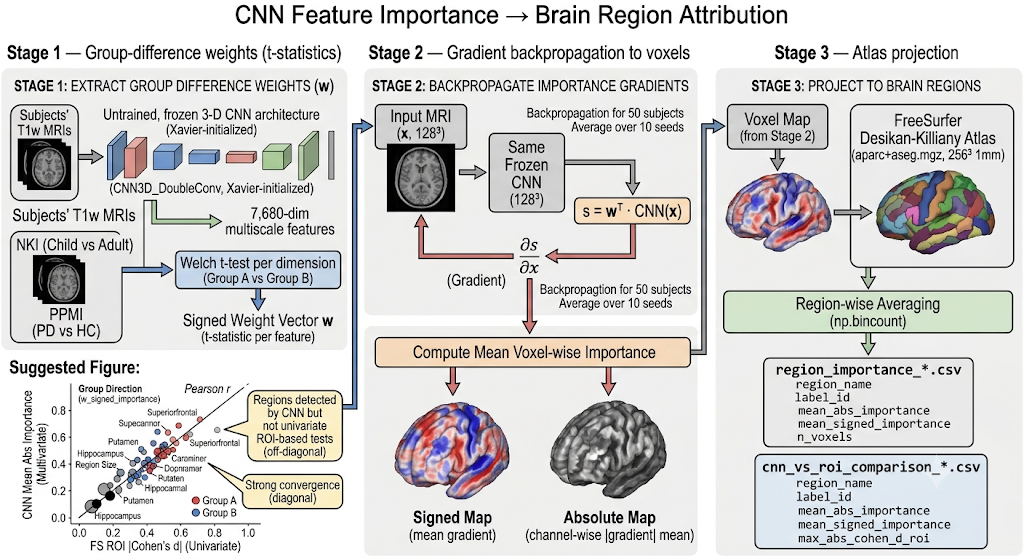